# Arboles de decision: del concepto al modelo reproducible

Este notebook acompana la guia en PDF. Construiremos un arbol de clasificacion, estudiaremos como elige sus divisiones y evaluaremos su desempeno con observaciones que el modelo no vio durante el entrenamiento.

> **Importante:** todos los pacientes son simulados. El ejemplo es exclusivamente educativo y no constituye una herramienta clinica.

## Objetivos

Al terminar podremos:

1. distinguir clasificacion de regresion;
2. interpretar nodos, ramas y hojas;
3. calcular la impureza de Gini;
4. separar entrenamiento y prueba sin fuga de informacion;
5. interpretar metricas, matriz de confusion e importancia de variables;
6. reconocer sobreajuste y limites de uso.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from arboles_decision.pipeline import (
    FEATURES, TARGET, evaluate_model, fit_model,
    gini_impurity, load_data, split_data, weighted_gini,
)

pd.set_option('display.max_columns', 20)
RANDOM_STATE = 42

## 1. La entrada: una tabla pequena y comprensible

Cada fila es un caso simulado. Las seis columnas predictoras son la entrada $X$ y `riesgo_alto` es la respuesta $y$. Con datos reales, antes de modelar tendriamos que documentar procedencia, consentimiento, valores ausentes, errores de medicion y posibles sesgos.

In [2]:
data = load_data(ROOT / 'data/raw/riesgo_clinico_simulado.csv')
print(f'Filas: {len(data)} | Columnas: {data.shape[1]}')
data.head()

Filas: 480 | Columnas: 8


,id,edad,presion_sistolica,colesterol,fumador,actividad_horas_semana,antecedente_familiar,riesgo_alto
0,1,25,99.2,170.8,1,4.4,1,0
1,2,76,129.1,181.7,1,3.2,1,1
2,3,44,128.5,145.0,0,3.9,0,0
3,4,57,111.6,148.6,0,5.9,0,0
4,5,42,104.0,303.1,0,2.4,0,0


In [3]:
summary = data[FEATURES + [TARGET]].describe().T
summary[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
edad,49.94,17.97,18.0,80.0
presion_sistolica,127.89,18.05,88.0,182.5
colesterol,196.22,34.83,115.0,303.1
fumador,0.25,0.43,0.0,1.0
actividad_horas_semana,2.96,1.97,0.2,10.0
antecedente_familiar,0.30,0.46,0.0,1.0
riesgo_alto,0.44,0.50,0.0,1.0


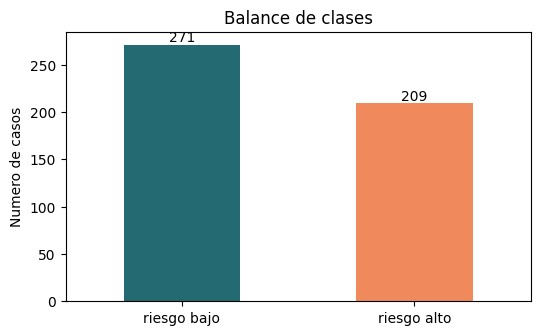

In [4]:
counts = data[TARGET].value_counts().sort_index()
ax = counts.rename(index={0: 'riesgo bajo', 1: 'riesgo alto'}).plot.bar(
    color=['#246A73', '#F08A5D'], rot=0, figsize=(6, 3.5)
)
ax.set(title='Balance de clases', xlabel='', ylabel='Numero de casos')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## 2. Separar antes de aprender

Reservamos 25% de los casos para la evaluacion final. `stratify=y` mantiene una proporcion semejante de ambas clases. La semilla fija hace que cualquier persona obtenga la misma particion.

In [5]:
X_train, X_test, y_train, y_test = split_data(data)
pd.DataFrame({
    'conjunto': ['entrenamiento', 'prueba'],
    'n': [len(X_train), len(X_test)],
    'proporcion_riesgo_alto': [y_train.mean(), y_test.mean()],
}).round(3)

,conjunto,n,proporcion_riesgo_alto
0,entrenamiento,360,0.436
1,prueba,120,0.433


## 3. Como decide una division: impureza de Gini

Para un nodo con proporciones de clase $p_k$, la impureza es

$$G = 1 - \sum_k p_k^2.$$

Un nodo puro tiene Gini 0. En clasificacion binaria, la mezcla 50/50 alcanza 0.5. El algoritmo compara divisiones candidatas y elige la que produce la menor impureza ponderada en los hijos.

In [6]:
examples = {
    'nodo puro': [0, 0, 0, 0],
    'nodo mezclado': [0, 0, 1, 1],
    'mezcla 3/1': [0, 0, 0, 1],
}
pd.Series({name: gini_impurity(labels) for name, labels in examples.items()}, name='Gini')

nodo puro        0.000
nodo mezclado    0.500
mezcla 3/1       0.375
Name: Gini, dtype: float64

In [7]:
left_child = [0, 0, 0, 1]
right_child = [1, 1, 1, 0]
print('Gini ponderado de la division:', round(weighted_gini(left_child, right_child), 3))

Gini ponderado de la division: 0.375


## 4. Entrenar un arbol interpretable

Limitamos la profundidad a 3 y exigimos al menos 20 observaciones por hoja. Estas restricciones reducen la complejidad y facilitan explicar el modelo. No son valores universales: en un proyecto real se elegirian mediante validacion cruzada y segun el costo de los errores.

In [8]:
model = fit_model(X_train, y_train)
print('Profundidad:', model.get_depth())
print('Numero de hojas:', model.get_n_leaves())
print('Variables consideradas:', model.n_features_in_)

Profundidad: 3
Numero de hojas: 8
Variables consideradas: 6


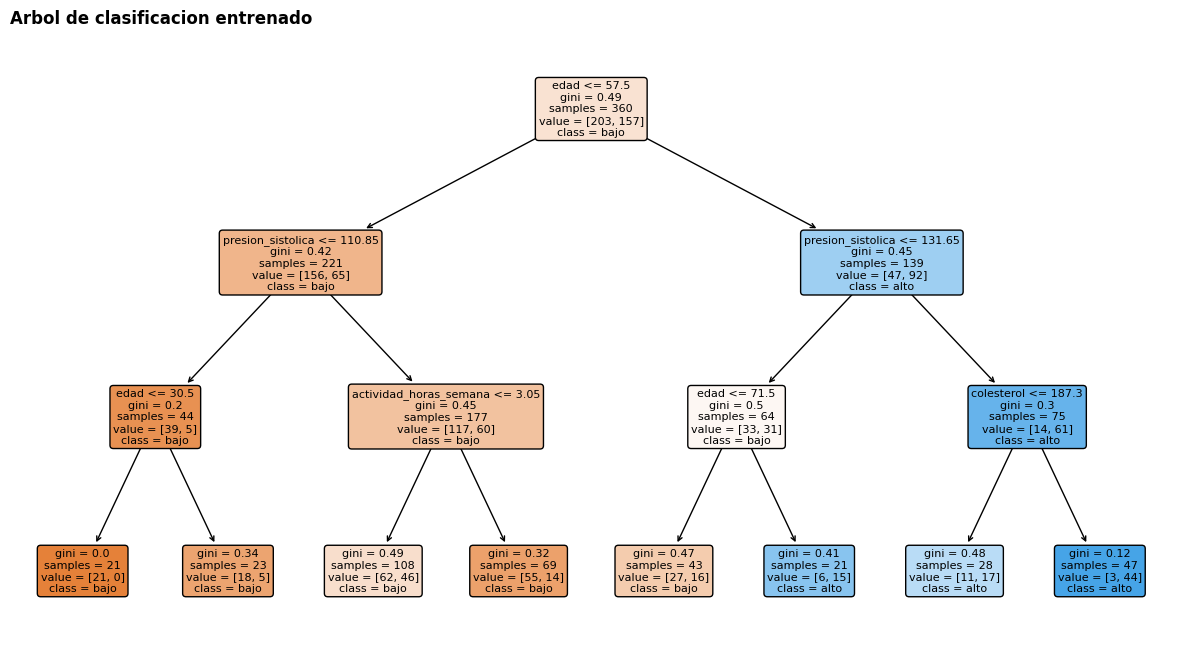

In [9]:
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(
    model, feature_names=FEATURES, class_names=['bajo', 'alto'],
    filled=True, rounded=True, fontsize=8, precision=2, ax=ax
)
ax.set_title('Arbol de clasificacion entrenado', loc='left', fontweight='bold')
plt.show()

### Como leer un nodo

La primera linea contiene una pregunta, por ejemplo `edad <= 56.5`. Si la respuesta es verdadera avanzamos a la izquierda; si es falsa, a la derecha. `samples` indica cuantos casos de entrenamiento llegaron al nodo; `value` cuenta las clases y `class` muestra la prediccion mayoritaria.

## 5. Evaluar con datos no vistos

No existe una unica metrica correcta. Exactitud resume aciertos totales; precision pregunta cuantos positivos predichos fueron positivos; sensibilidad (`recall`) pregunta cuantos positivos reales encontramos; F1 equilibra precision y sensibilidad; ROC AUC estudia el ordenamiento de probabilidades a traves de distintos umbrales.

In [10]:
metrics, predicted, probability = evaluate_model(model, X_test, y_test)
baseline = max(y_test.mean(), 1 - y_test.mean())
metric_table = pd.Series({**metrics, 'baseline_accuracy': baseline})
metric_table.round(3).to_frame('valor')

,valor
accuracy,0.733
precision,0.794
recall,0.519
f1,0.628
roc_auc,0.724
baseline_accuracy,0.567


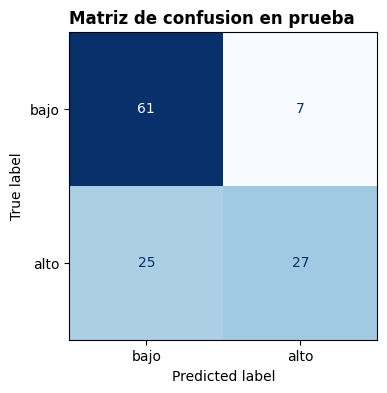

In [11]:
matrix = confusion_matrix(y_test, predicted)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matrix, display_labels=['bajo', 'alto']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Matriz de confusion en prueba', loc='left', fontweight='bold')
plt.show()

In [12]:
examples = X_test.copy()
examples.insert(0, 'id', data.loc[X_test.index, 'id'])
examples['observado'] = y_test
examples['predicho'] = predicted
examples['probabilidad_riesgo_alto'] = probability
examples.sort_values('probabilidad_riesgo_alto', ascending=False).head(8).round(3)

,id,edad,presion_sistolica,colesterol,fumador,actividad_horas_semana,antecedente_familiar,observado,predicho,probabilidad_riesgo_alto
310,311,65,138.8,227.5,0,2.7,1,1,1,0.936
274,275,60,140.3,238.1,0,3.6,0,1,1,0.936
290,291,70,147.7,189.1,0,5.1,0,1,1,0.936
419,420,67,141.2,208.8,0,2.2,0,1,1,0.936
248,249,68,182.5,193.8,0,0.6,0,1,1,0.936
30,31,68,152.7,300.9,0,2.1,1,1,1,0.936
343,344,59,168.8,198.7,1,4.7,1,1,1,0.936
342,343,63,162.0,220.7,0,1.6,0,1,1,0.936


## 6. Importancia y sobreajuste

La importancia de una variable suma cuanto redujo la impureza en las divisiones donde fue utilizada. Es una descripcion interna de este arbol, no demuestra causalidad. Ademas, un arbol mas profundo casi siempre mejora el ajuste al entrenamiento, pero puede empeorar en casos nuevos.

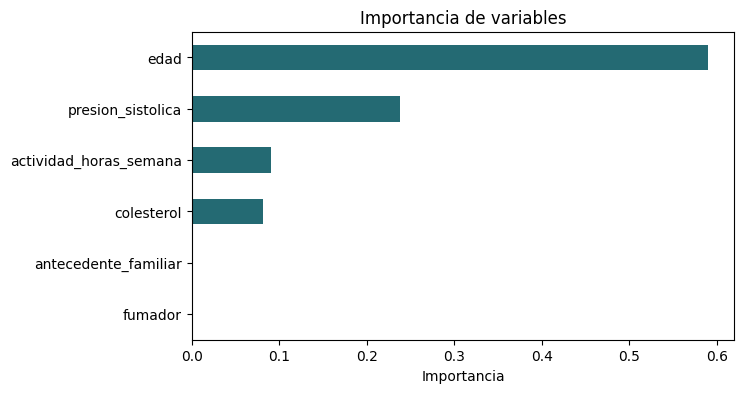

In [13]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
ax = importance.plot.barh(color='#246A73', figsize=(7, 4))
ax.set(title='Importancia de variables', xlabel='Importancia', ylabel='')
plt.show()

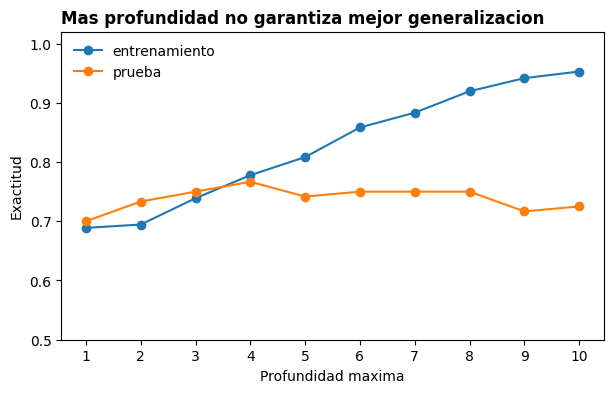

In [14]:
depths = range(1, 11)
train_scores, test_scores = [], []
for depth in depths:
    candidate = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    candidate.fit(X_train, y_train)
    train_scores.append(candidate.score(X_train, y_train))
    test_scores.append(candidate.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(list(depths), train_scores, marker='o', label='entrenamiento')
plt.plot(list(depths), test_scores, marker='o', label='prueba')
plt.xlabel('Profundidad maxima')
plt.ylabel('Exactitud')
plt.ylim(0.5, 1.02)
plt.xticks(list(depths))
plt.legend(frameon=False)
plt.title('Mas profundidad no garantiza mejor generalizacion', loc='left', fontweight='bold')
plt.show()

## 7. Clasificacion y regresion

Este ejemplo es de **clasificacion** porque $y$ contiene categorias. Un arbol de **regresion** conserva la estructura de preguntas, pero predice una cantidad continua y suele elegir divisiones que reducen el error cuadratico. Por ejemplo: predecir concentracion, tiempo de estancia o costo.

## 8. Lo que debemos decir al presentar resultados

- El arbol ofrece reglas faciles de seguir, pero pequenas variaciones en los datos pueden cambiar su estructura.
- La exactitud debe compararse con una referencia y complementarse con metricas sensibles al tipo de error.
- La importancia no implica causalidad.
- La interpretabilidad no elimina la necesidad de validacion externa, revision de sesgo y juicio profesional.
- Un ejemplo simulado demuestra el flujo tecnico, no el rendimiento que se obtendria en una poblacion real.

## Ejercicios sugeridos

1. Cambiar `max_depth` de 3 a 1 y comparar la interpretacion y las metricas.
2. Cambiar `criterion='gini'` por `criterion='entropy'`.
3. Explicar un falso negativo de la matriz de confusion.
4. Proponer una metrica principal si omitir un caso de riesgo alto fuera mucho mas costoso.
5. Enumerar tres comprobaciones adicionales necesarias antes de usar datos reales.